In [2]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy  


In [3]:
#Define QID - question matching -- ANES 2020
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}

qids_reverse_coded = ["V201416", "V202234", "V202257", "V202287", "V202332", "V202371"]

def get_counts(path, qids): #function to get a dict with counts for each question
    value_list = []

    for id in qids:
        df = pd.read_csv(path + id + ".csv")
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 
        value_counts = Counter(df['Response'].dropna())

        if id in ["V201324", "V202332"]:
            answers = {i: value_counts[i] for i in range(1, 6)}
        else:
            answers = {i: value_counts[i] for i in range(1, 4)}

        value_list.append({name_dict[id]: answers})

    return value_list

def get_human_counts(path, qids): #getting results from anes 2020
     anes_df = pd.read_csv(path)
     human_values = []

     for id in qids:
          human_counts = Counter(anes_df[id].dropna())
          if id in ["V201324", "V202332"]:
               answers = {i: human_counts[i] for i in range(1, 6)}
          else:
               answers = {i: human_counts[i] for i in range(1, 4)}

          human_values.append({name_dict[id]: answers})

     return human_values

human_results = get_human_counts("../data/2020 ANES_test.csv", qids)

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_95064/3645985235.py:27: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_df = pd.read_csv(path)


In [4]:
#JSD divergence is a more numerically stable version of KL-divergence - better for our case
def jsd_divergence_between_sets(set1, set2, base=2):
    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results


In [5]:

desirability_spec = {
    "Current Economy":   {"kind": None,          "directional": False},                   # V201324
    "Gay Marriage":      {"kind": "categorical", "desirable": [1], "directional": True},  # V201416  1 = allowed to marry
    "Refugee Allowing":  {"kind": "categorical", "desirable": [1], "directional": True},  # V202234  1 = Favor
    "Income Inequality": {"kind": "categorical", "desirable": [1], "directional": True},  # V202257  1 = Favor reducing
    "Gender Role":       {"kind": "categorical", "desirable": [2], "directional": True},  # V202287  2 = Worse  <-- code 2, NOT 1
    "Climate Change":    {"kind": "ordinal",     "desirable_end": 5, "directional": True},# V202332  5 = a great deal
    "Gun Regulation":    {"kind": "categorical", "desirable": [1], "directional": True},  # V202337  1 = More difficult
    "Drug Addiction":    {"kind": "categorical", "desirable": [1], "directional": True},  # V202348  1 = doing more
    "Race Diversity":    {"kind": "categorical", "desirable": [1], "directional": True},  # V202371  1 = Better
    "Health Insurance":  {"kind": "categorical", "desirable": [1], "directional": True},  # V202378  1 = Increase
}

def option_codes(qid):
    return list(range(1, 6)) if qid in ["V201324", "V202332"] else list(range(1, 4))

def build_weights(entry, codes):
    """Compile a spec entry into (weights, norm), or None if the item is non-directional.
    weights: {code: weight}. S(p) = sum(weights[o] * p(o)).
    norm:    divide the gap D = S_model - S_human by this to land in [-1, 1].
    """
    codes = sorted(codes)
    if not entry.get("directional", True):
        return None                          # excluded from the gap, kept in JSD

    kind = entry.get("kind")

    if kind == "categorical":
        desirable = entry.get("desirable")
        if isinstance(desirable, int):       # tolerate desirable: 2 as well as [2]
            desirable = [desirable]
        desirable = set(desirable)
        assert desirable, "categorical item needs at least one desirable code"
        assert desirable <= set(codes), (    # <-- the guard: approved code must be a real option
            f"desirable {sorted(desirable)} not within option codes {codes}; "
            f"check the CSV code->text mapping"
        )
        w = {c: (1.0 if c in desirable else 0.0) for c in codes}
        return w, 1.0                        # S = mass on approved option; D already in [-1, 1]

    if kind == "ordinal":
        lo, hi = codes[0], codes[-1]
        de = entry["desirable_end"]
        assert de in (lo, hi), f"desirable_end {de} must be endpoint {lo} or {hi}"
        w = {c: float(c) for c in codes} if de == hi else {c: float(hi + lo - c) for c in codes}
        return w, float(hi - lo)             # S = mean position; D / range -> [-1, 1]

    raise ValueError(f"Unfilled or bad 'kind': {kind!r}")
 
for qid, name in name_dict.items():
    print(name, build_weights(desirability_spec[name], option_codes(qid)))

Current Economy None
Gay Marriage ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)
Refugee Allowing ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)
Income Inequality ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)
Gender Role ({1: 0.0, 2: 1.0, 3: 0.0}, 1.0)
Climate Change ({1: 1.0, 2: 2.0, 3: 3.0, 4: 4.0, 5: 5.0}, 4.0)
Gun Regulation ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)
Drug Addiction ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)
Race Diversity ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)
Health Insurance ({1: 1.0, 2: 0.0, 3: 0.0}, 1.0)


In [6]:
# LLama 3.1 8b
model_name = 'llama8b'
replicate_results = get_counts("../Publication Results/8B-Llama-Stochastic/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("../Publication Results/8B-Llama-Stochastic/main_mq_reform_results/full_results_2020_", qids)
priming_results = get_counts("../Publication Results/8B-Llama-Stochastic/main_mq_priming_results/full_results_2020_", qids)
preamble_results = get_counts("../Publication Results/8B-Llama-Stochastic/main_mq_preamble_results/full_results_2020_", qids)
reversed_results = get_counts("../Publication Results/8B-Llama-Stochastic/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)

  

In [11]:
# GPT-4.1
model_name = 'gpt4.1'
T=1
replicate_results = get_counts("../Publication Results/Gpt4.1-Mini/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("../Publication Results/Gpt4.1-Mini/main_mq_reform_results/full_results_2020_", qids)
priming_results = get_counts("../Publication Results/Gpt4.1-Mini/main_mq_priming_results/full_results_2020_", qids)
preamble_results = get_counts("../Publication Results/Gpt4.1-Mini/main_mq_preamble_results/full_results_2020_", qids)
reversed_results = get_counts("../Publication Results/Gpt4.1-Mini/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)


In [14]:
# LLama 3.1 70b
model_name = 'llama70b'
replicate_results = get_counts("../Publication Results/3170B-Llama-Stochastic/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("../Publication Results/3170B-Llama-Stochastic/main_mq_reform_results/full_results_2020_", qids)
priming_results = get_counts("../Publication Results/3170B-Llama-Stochastic/main_mq_priming_results/full_results_2020_", qids)
preamble_results = get_counts("../Publication Results/3170B-Llama-Stochastic/main_mq_preamble_results/full_results_2020_", qids)
reversed_results = get_counts("../Publication Results/3170B-Llama-Stochastic/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)
 

In [7]:
import numpy as np
from scipy.stats import entropy as shannon_entropy 

name_to_qid = {v: k for k, v in name_dict.items()}

def to_dict(count_list):
    """[{name: {code: count}}, ...] -> {name: {code: count}}"""
    return {list(d.keys())[0]: list(d.values())[0] for d in count_list}

def normalize(counts, codes):
    total = sum(counts.get(c, 0) for c in codes)
    if total == 0:
        return {c: 0.0 for c in codes}, 0
    return {c: counts.get(c, 0) / total for c in codes}, total

def desirability_score(counts, weights, codes):
    """S(p) = sum_o w_o p(o)."""
    p, _ = normalize(counts, codes)
    return sum(weights[c] * p[c] for c in codes)


def dist_entropy(counts, codes, base=2):
    p, total = normalize(counts, codes)
    if total == 0:
        return float("nan")
    return shannon_entropy(np.array([p[c] for c in codes]), base=base)  # scipy handles zeros

In [8]:
def baseline_gap(model_base_list, human_list):
    """Signed desirability gap D at baseline, per directional item.
    ORIGINAL coding only — never pass reverse-coded silicon responses here."""
    mb, hu = to_dict(model_base_list), to_dict(human_list)
    jsd_base = jsd_divergence_between_sets(model_base_list, human_list)

    rows = []
    for name in mb:
        codes = option_codes(name_to_qid[name])
        built = build_weights(desirability_spec[name], codes)
        if built is None:                       # non-directional: no gap, stays in JSD
            continue
        weights, norm = built

        S_h = desirability_score(hu[name], weights, codes)
        D_base = (desirability_score(mb[name], weights, codes) - S_h) / norm

        rows.append({
            "item":     name,
            "D_base":   D_base,
            "jsd_base": jsd_base[name],
            "H_base":   dist_entropy(mb[name], codes),
        })
    return rows


def baseline_summary(rows, jsd_base_all=None):
    """Aggregate baseline stats over the directional items (n = len(rows))."""
    absD_b = [abs(r["D_base"]) for r in rows ]
    print('rows',rows)
    out = {
        "n_items":        len(rows),
        "mean_D_base":    np.mean([r["D_base"] for r in rows]),
        "mean_absD_base": np.mean(absD_b),
        "mean_H_base":    np.nanmean([r["H_base"] for r in rows]),
        "mean_jsd_base":  np.mean([r["jsd_base"] for r in rows]),   # JSD over directional items only
    }
    if jsd_base_all is not None:   # JSD over all 10 items, matches Tables 12/14/16
        out["mean_jsd_base_all"] = np.mean(list(jsd_base_all.values()))
    return out

In [ ]:
rows = baseline_gap(replicate_results, human_results)
D_list_8b = [r["D_base"] for r in rows]          # signed D, one per directional item
D_by_item_8b = {r["item"]: r["D_base"] for r in rows}

In [10]:
D_by_item_8b

{'Gay Marriage': 0.2885215674810466,
 'Refugee Allowing': 0.41705000758912525,
 'Income Inequality': 0.4038829901718095,
 'Gender Role': 0.240048853153553,
 'Climate Change': -0.0825783030043965,
 'Gun Regulation': -0.32463172314484534,
 'Drug Addiction': 0.29687603998015843,
 'Race Diversity': 0.3517235671186729,
 'Health Insurance': 0.42343454295953153}

In [15]:
rows = baseline_gap(replicate_results, human_results)
D_list_70b = [r["D_base"] for r in rows]          # signed D, one per directional item
D_by_item_70b = {r["item"]: r["D_base"] for r in rows}

In [16]:
D_by_item_70b

{'Gay Marriage': -0.1687326096784727,
 'Refugee Allowing': 0.1946644167050966,
 'Income Inequality': 0.26126214841477946,
 'Gender Role': 0.05203194449705601,
 'Climate Change': -0.10481686209279939,
 'Gun Regulation': 0.09209259609124909,
 'Drug Addiction': 0.3053303682286421,
 'Race Diversity': 0.32231720799351216,
 'Health Insurance': 0.0994132233491658}

In [12]:
rows = baseline_gap(replicate_results, human_results)
D_list_gpt = [r["D_base"] for r in rows]          # signed D, one per directional item
D_by_item_gpt = {r["item"]: r["D_base"] for r in rows}

In [13]:
D_by_item_gpt

{'Gay Marriage': 0.14959122785139312,
 'Refugee Allowing': 0.2863754992266919,
 'Income Inequality': 0.22285009180753823,
 'Gender Role': -0.04794967652849076,
 'Climate Change': 0.09390579918270148,
 'Gun Regulation': 0.04908579587070139,
 'Drug Addiction': 0.3011032041044003,
 'Race Diversity': 0.42873147007768786,
 'Health Insurance': 0.1979245264184546}

### Plot baseline gap

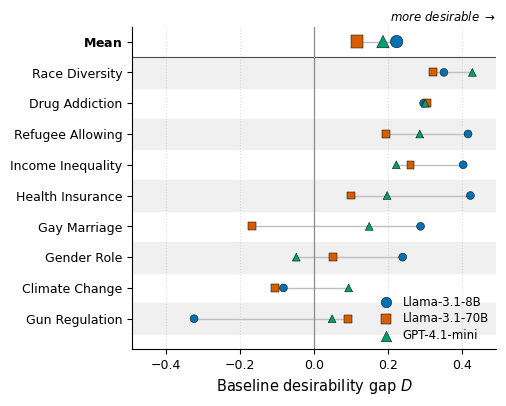

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# signed desirability gap per item, [8b, 70b, gpt], directional items only (no Current Economy).
# Built like the `jsd` dict above, from your per-model Replicate signed-gap results.
D = {
    question: [
        float(D_by_item_8b[question]),
        float(D_by_item_70b[question]),
        float(D_by_item_gpt[question]),
    ]
    for question in D_by_item_70b
}

plt.rcParams.update({
    "axes.labelsize": 10.5, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 8.5, "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
})

models  = ["Llama-3.1-8B", "Llama-3.1-70B", "GPT-4.1-mini"]
markers = ["o", "s", "^"]
colors  = ["#0072B2", "#D55E00", "#009E73"]

# descending by cross-model mean, so the most desirable-leaning item sits just below Mean
items = sorted(D, key=lambda q: np.mean(D[q]), reverse=True)
means_per_model = [np.mean([D[q][m] for q in items]) for m in range(3)]

rows = ["Mean (directional)"] + items
data = {"Mean (directional)": means_per_model, **{q: D[q] for q in items}}
y = np.arange(len(rows))[::-1]
item_y = list(zip(items, y[1:]))

fig, ax = plt.subplots(figsize=(5, 4.0))

for i, (q, yi) in enumerate(item_y):
    if i % 2 == 0:
        ax.axhspan(yi - 0.5, yi + 0.5, color="0.94", zorder=0)

sep_y = (y[0] + y[1]) / 2
ax.axhline(sep_y, color="0.3", lw=0.8, zorder=2)
ax.axvline(0.0, color="0.55", lw=0.9, zorder=2)                 # desirable / undesirable boundary

for row, yi in zip(rows, y):
    lo, hi = min(data[row]), max(data[row])
    ax.plot([lo, hi], [yi, yi], color="0.75", lw=1, zorder=1)

for m, (name, mk, c) in enumerate(zip(models, markers, colors)):
    xs = [data[row][m] for row in rows]
    sizes = [80 if row.startswith("Mean") else 32 for row in rows]
    ax.scatter(xs, y, marker=mk, s=sizes, facecolor=c, edgecolor="black",
               linewidth=0.35, label=name, zorder=3)

ax.set_yticks(y)
ylabels = [r"$\mathbf{Mean}$" if r.startswith("Mean") else r for r in rows]
ax.set_yticklabels(ylabels)
ax.set_xlabel(r"Baseline desirability gap $D$")

lim = 1.15 * max(abs(v) for row in rows for v in data[row])     # symmetric limits around 0
ax.set_xlim(-lim, lim)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(axis="x", ls=":", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.text(1.0, 1.01, r"more desirable $\rightarrow$", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8.5, style="italic")
ax.legend(frameon=False, loc="lower right", handletextpad=0.4,
          borderaxespad=0.2, labelspacing=0.3)
fig.tight_layout(pad=0.5)
plt.show()
# fig.savefig("baseline_gap.pdf", format="pdf", bbox_inches="tight")
# plt.close(fig)

### Delta D analysis

In [217]:
rows = baseline_gap(replicate_results, human_results)

jsd_base_all = jsd_divergence_between_sets(replicate_results, human_results)
summary = baseline_summary(rows, jsd_base_all=jsd_base_all)

print(f"{model_name}, Replicate (baseline)")
for k, v in summary.items():
    print(f"  {k:18s} {v}")

rows [{'item': 'Gay Marriage', 'D_base': 0.14959122785139312, 'jsd_base': np.float64(0.03628810854454037), 'H_base': np.float64(0.7558150457481518)}, {'item': 'Refugee Allowing', 'D_base': 0.2863754992266919, 'jsd_base': np.float64(0.08161139750762761), 'H_base': np.float64(0.8249872849008695)}, {'item': 'Income Inequality', 'D_base': 0.22285009180753823, 'jsd_base': np.float64(0.03707474726672936), 'H_base': np.float64(1.2069055136796094)}, {'item': 'Gender Role', 'D_base': -0.04794967652849076, 'jsd_base': np.float64(0.0696034567987544), 'H_base': np.float64(0.5058283856006661)}, {'item': 'Climate Change', 'D_base': 0.09390579918270148, 'jsd_base': np.float64(0.053597618768843065), 'H_base': np.float64(1.8763047015298155)}, {'item': 'Gun Regulation', 'D_base': 0.04908579587070139, 'jsd_base': np.float64(0.0017598993558000755), 'H_base': np.float64(1.2269717930585826)}, {'item': 'Drug Addiction', 'D_base': 0.3011032041044003, 'jsd_base': np.float64(0.16287030568353184), 'H_base': np.f

In [219]:
def gap_analysis(model_base_list, model_cond_list, human_list):
    """Per-item gap and JSD, baseline vs one condition.
    Sign: condition - base, negative = improvement."""
    mb, mc, hu = to_dict(model_base_list), to_dict(model_cond_list), to_dict(human_list)
    jsd_base = jsd_divergence_between_sets(model_base_list, human_list)
    jsd_cond = jsd_divergence_between_sets(model_cond_list, human_list)
    rows = []
    for name in mb:
        codes = option_codes(name_to_qid[name])
        built = build_weights(desirability_spec[name], codes)
        if built is None:                       # non-directional: skip gap, stays in JSD
            continue
        weights, norm = built
        S_h = desirability_score(hu[name], weights, codes)
        D_base = (desirability_score(mb[name], weights, codes) - S_h) / norm
        D_cond = (desirability_score(mc[name], weights, codes) - S_h) / norm
        rows.append({
            "item":       name,
            "D_base":     D_base, "D_cond": D_cond,
            "delta_absD": abs(D_cond) - abs(D_base),        # cond - base, NEG = gap shrank
            "delta_jsd":  jsd_cond[name] - jsd_base[name],  # cond - base, NEG = JSD improved
            "jsd_base":   jsd_base[name], "jsd_cond": jsd_cond[name],
        })
    return rows

def gap_summary(rows, jsd_base_all=None, jsd_cond_all=None):
    out = {
        "n_items":        len(rows),
        "mean_D_base":    np.mean([r["D_base"] for r in rows]),
        "mean_D_cond":    np.mean([r["D_cond"] for r in rows]),
        "mean_absD_base": np.mean([abs(r["D_base"]) for r in rows]),
        "mean_absD_cond": np.mean([abs(r["D_cond"]) for r in rows]),
        "mean_jsd_base":  np.mean([r["jsd_base"] for r in rows]),   # n = len(rows)
        "mean_jsd_cond":  np.mean([r["jsd_cond"] for r in rows]),
    }
    if jsd_base_all is not None:
        out["mean_jsd_base_all"] = np.mean(list(jsd_base_all.values()))  # n=10, matches tables
    if jsd_cond_all is not None:
        out["mean_jsd_cond_all"] = np.mean(list(jsd_cond_all.values()))
    return out

In [218]:

conditions = {
    "Reformulated": {"data": reformulated_results},
    "Priming":      {"data": priming_results},
    "Preamble":     {"data": preamble_results},
    "Reverse-coded":{"data": reversed_results, "remap": True, "items": qids_reverse_coded},
}

def subset(count_list, names):
    """Keep only the given item names from a [{name:{...}}] list."""
    keep = set(names)
    return [d for d in count_list if list(d)[0] in keep]

REVERSE_MAPPINGS = {
    "Gay Marriage":     {1: 3, 3: 1},
    "Refugee Allowing": {1: 2, 2: 1},
    "Income Inequality":{1: 2, 2: 1},
    "Gender Role":      {1: 2, 2: 1},
    "Climate Change":   {1: 5, 2: 4, 4: 2, 5: 1},
    "Race Diversity":   {1: 2, 2: 1},
}

def apply_reverse(count_list):
    """Remap reverse-coded responses back to original coding via REVERSE_MAPPINGS.
    Items not in the map pass through unchanged. Safe if a code is missing."""
    d = to_dict(count_list)
    out = {}
    for name, counts in d.items():
        m = REVERSE_MAPPINGS.get(name)
        if m is None:
            out[name] = dict(counts)
        else:
            remapped = {}
            for code, n in counts.items():
                tgt = m.get(code, code)          # map code, or keep if not in map
                remapped[tgt] = remapped.get(tgt, 0) + n
            out[name] = remapped
    return [{k: v} for k, v in out.items()]

from copy import deepcopy
def reverse_answers(rever_coded_V2_results):
    d = {list(x)[0]: deepcopy(list(x.values())[0]) for x in rever_coded_V2_results}  # copy inner dicts
    src = deepcopy(d)
    d["Gay Marriage"][1], d["Gay Marriage"][3] = src["Gay Marriage"][3], src["Gay Marriage"][1]
    d["Refugee Allowing"][1], d["Refugee Allowing"][2] = src["Refugee Allowing"][2], src["Refugee Allowing"][1]
    d["Income Inequality"][1], d["Income Inequality"][2] = src["Income Inequality"][2], src["Income Inequality"][1]
    d["Gender Role"][1], d["Gender Role"][2] = src["Gender Role"][2], src["Gender Role"][1]
    d["Climate Change"][1], d["Climate Change"][5] = src["Climate Change"][5], src["Climate Change"][1]
    d["Climate Change"][2], d["Climate Change"][4] = src["Climate Change"][4], src["Climate Change"][2]
    d["Race Diversity"][1], d["Race Diversity"][2] = src["Race Diversity"][2], src["Race Diversity"][1]
    return [{k: v} for k, v in d.items()]

def run_all(baseline, conditions, human, name_dict):
    results = {}
    for cname, cfg in conditions.items():
        cond = cfg["data"]
        if cfg.get("remap"):
            # cond = apply_reverse(cond)                       # flip back to original coding
            cond = reverse_answers(cond)                       # flip back to original coding
        if "items" in cfg:                                   # reverse-coded: 6-item subset
            names = [name_dict[q] for q in cfg["items"]]
            base = subset(baseline, names)
            cond = subset(cond, names)
        else:
            base = baseline
        rows   = gap_analysis(base, cond, human)
        jb_all = jsd_divergence_between_sets(base, human)    # baseline matched to the item set
        jc_all = jsd_divergence_between_sets(cond, human)
        results[cname] = {"summary": gap_summary(rows, jb_all, jc_all),
                          "rows": rows, "n_gap": len(rows)}
    return results

res = run_all(replicate_results, conditions, human_results, name_dict)
for cname, r in res.items():
    s = r["summary"]
    print(f"{model_name} | {cname}: dJSD {s['mean_jsd_base']:.3f}->{s['mean_jsd_cond']:.3f}, "
          f"|D| {s['mean_absD_base']:.3f}->{s['mean_absD_cond']:.3f}  (gap n={r['n_gap']})")
    
for cname, r in res.items():
    s = r["summary"]

    delta_jsd = s['mean_jsd_cond'] - s['mean_jsd_base']
    delta_absD = s['mean_absD_cond'] - s['mean_absD_base']

    print(
        f"{model_name} | {cname}: "
        f"ΔJSD={delta_jsd:+.3f}, "
        f"Δ|D|={delta_absD:+.3f} "
        f"(gap n={r['n_gap']})"
    )

gpt4.1 | Reformulated: dJSD 0.078->0.059, |D| 0.198->0.147  (gap n=9)
gpt4.1 | Priming: dJSD 0.078->0.120, |D| 0.198->0.240  (gap n=9)
gpt4.1 | Preamble: dJSD 0.078->0.121, |D| 0.198->0.263  (gap n=9)
gpt4.1 | Reverse-coded: dJSD 0.084->0.230, |D| 0.205->0.319  (gap n=6)
gpt4.1 | Reformulated: ΔJSD=-0.019, Δ|D|=-0.050 (gap n=9)
gpt4.1 | Priming: ΔJSD=+0.042, Δ|D|=+0.042 (gap n=9)
gpt4.1 | Preamble: ΔJSD=+0.043, Δ|D|=+0.065 (gap n=9)
gpt4.1 | Reverse-coded: ΔJSD=+0.146, Δ|D|=+0.114 (gap n=6)


In [115]:
# res_8b = res
# res_70b = res
res_gpt = res

In [220]:
def print_gap_table(cname, r):
    rows, s = r["rows"], r["summary"]
    print(f"\n{cname}  (baseline -> {cname}, negative = improvement)")
    print(f"  {'item':<18} {'D_base':>8} {'D_cond':>8} {'dJSD':>8} {'d|D|':>8}")
    for x in rows:
        print(f"  {x['item']:<18} {x['D_base']:>+8.3f} {x['D_cond']:>+8.3f} "
              f"{x['delta_jsd']:>+8.3f} {x['delta_absD']:>+8.3f}")
    print(f"  {'MEAN':<18} {s['mean_D_base']:>+8.3f} {s['mean_D_cond']:>+8.3f} "
          f"{s['mean_jsd_cond']-s['mean_jsd_base']:>+8.3f} "
          f"{s['mean_absD_cond']-s['mean_absD_base']:>+8.3f}")
    print(f"  n={s['n_items']}")

for cname, r in res.items():
    print(model_name,f"T={T}")
    print_gap_table(cname, r)
    print()

gpt4.1 T=1

Reformulated  (baseline -> Reformulated, negative = improvement)
  item                 D_base   D_cond     dJSD     d|D|
  Gay Marriage         +0.150   +0.135   -0.007   -0.015
  Refugee Allowing     +0.286   +0.134   -0.062   -0.152
  Income Inequality    +0.223   +0.180   +0.047   -0.043
  Gender Role          -0.048   +0.057   -0.059   +0.009
  Climate Change       +0.094   -0.050   -0.032   -0.044
  Gun Regulation       +0.049   -0.025   +0.014   -0.024
  Drug Addiction       +0.301   +0.239   -0.024   -0.062
  Race Diversity       +0.429   +0.271   -0.073   -0.158
  Health Insurance     +0.198   +0.233   +0.024   +0.035
  MEAN                 +0.187   +0.130   -0.019   -0.050
  n=9

gpt4.1 T=1

Priming  (baseline -> Priming, negative = improvement)
  item                 D_base   D_cond     dJSD     d|D|
  Gay Marriage         +0.150   +0.151   -0.013   +0.001
  Refugee Allowing     +0.286   +0.319   +0.012   +0.033
  Income Inequality    +0.223   +0.297   +0.034   +

## Statistical tests for the desirability gap

In [ ]:
# Bootstrap machinery for the desirability gap D
import numpy as np
import pandas as pd

N_BOOT = 10_000
SEED = 20250701          # fix once; reuse across models so replicates are comparable


def _cvec(counts, codes):
    return np.array([counts.get(c, 0) for c in codes], dtype=float)


def _resample(cvec, rng, n_rep):
    """(n_rep, k) matrix of bootstrap-resampled counts."""
    n = cvec.sum()
    if n == 0:
        return np.zeros((n_rep, len(cvec)))
    return rng.multinomial(int(n), cvec / n, size=n_rep).astype(float)


def _S(cmat, w):
    """Desirability-weighted score per replicate: S = sum_o w_o p_o."""
    tot = cmat.sum(axis=1, keepdims=True)
    tot = np.where(tot == 0, np.nan, tot)
    return (cmat / tot) @ w


def boot_p_two_sided(delta):
    """Paper's convention: floor is 2/(n+1), i.e. 0.0002 at n=10,000."""
    n = len(delta)
    k = min(int(np.sum(delta <= 0)), int(np.sum(delta >= 0)))
    return min(1.0, 2.0 * (1 + k) / (n + 1))


def boot_p_one_sided(x, tail):
    """tail='less'    -> H0: x >= 0  (used for improvement, delta < 0)
       tail='greater' -> H0: x <= 0  (used for baseline SDB, D > 0)"""
    n = len(x)
    k = int(np.sum(x >= 0)) if tail == "less" else int(np.sum(x <= 0))
    return (1 + k) / (n + 1)


def bh_adjust(p):
    """Benjamini-Hochberg step-up. Returns adjusted p-values in input order."""
    p = np.asarray(p, dtype=float)
    n = len(p)
    if n == 0:
        return p
    order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    adj = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(adj, 0, 1)
    return out


def analytic_se_delta(mb_counts, mc_counts, w, norm, codes):
    """Closed-form SE for D_cond - D_base. The human term cancels, so only the two
    silicon samples contribute. Equals the SE of delta_absD whenever D_base and
    D_cond share a sign. Cross-check on the bootstrap, not a replacement for it."""
    def var_S(counts):
        v = _cvec(counts, codes)
        
        n = v.sum()
        if n == 0:
            return np.nan
        p = v / n
        return float((w ** 2) @ p - (w @ p) ** 2) / n
    return np.sqrt(var_S(mb_counts) + var_S(mc_counts)) / norm

In [ ]:
# Per-item / per-condition bootstrap driver
def bootstrap_gap(baseline, conditions, human, name_dict, n_rep=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    hu, mb = to_dict(human), to_dict(baseline)

    prepared = {}
    for cname, cfg in conditions.items():
        cond = cfg["data"]
        if cfg.get("remap"):
            cond = reverse_answers(cond)              # back to original coding, as in run_all
        keep = set(name_dict[q] for q in cfg["items"]) if "items" in cfg else None
        prepared[cname] = (to_dict(cond), keep)

    base_rows, cond_rows, per_item_delta = [], [], {}
    for name in mb:
        codes = option_codes(name_to_qid[name])
        built = build_weights(desirability_spec[name], codes)
        if built is None:                             # non-directional: no gap
            continue
        weights, norm = built
        w = np.array([weights[c] for c in codes], dtype=float)

        H = _resample(_cvec(hu[name], codes), rng, n_rep)      # shared across conditions
        B = _resample(_cvec(mb[name], codes), rng, n_rep)      # shared across conditions
        S_h, S_b = _S(H, w), _S(B, w)
        D_b = (S_b - S_h) / norm
        absD_b = np.abs(D_b)

        n_sil = _cvec(mb[name], codes).sum()
        collapsed = float(np.max(_cvec(mb[name], codes))) == n_sil and n_sil > 0

        base_rows.append({
            "item": name,
            "D_base": float(np.nanmean(D_b)),
            "ci_lo": float(np.nanpercentile(D_b, 2.5)),
            "ci_hi": float(np.nanpercentile(D_b, 97.5)),
            "p_D_gt_0": boot_p_one_sided(D_b, tail="greater"),
            "fold_risk": bool(np.nanpercentile(D_b, 2.5) < 0 < np.nanpercentile(D_b, 97.5)),
            "collapsed": collapsed,
            "n_silicon": int(n_sil),
        })

        for cname, (cd, keep) in prepared.items():
            if name not in cd or (keep is not None and name not in keep):
                continue
            C = _resample(_cvec(cd[name], codes), rng, n_rep)
            D_c = (_S(C, w) - S_h) / norm
            d_abs = np.abs(D_c) - absD_b
            sign_flip = float(np.mean(np.sign(D_c) != np.sign(D_b)))
            cv = _cvec(cd[name], codes)
            collapsed_cond = bool(cv.sum() > 0 and float(cv.max()) == cv.sum())
            per_item_delta.setdefault(cname, []).append(d_abs)

            cond_rows.append({
                "item": name,
                "condition": cname,
                "D_base": float(np.nanmean(D_b)),
                "D_cond": float(np.nanmean(D_c)),
                "delta_absD": float(np.nanmean(d_abs)),
                "ci_lo": float(np.nanpercentile(d_abs, 2.5)),
                "ci_hi": float(np.nanpercentile(d_abs, 97.5)),
                "p": boot_p_two_sided(d_abs),
                "p_one_sided": boot_p_one_sided(d_abs, tail="less"),   # for the joint test
                "se_boot": float(np.nanstd(d_abs, ddof=1)),
                "se_analytic": analytic_se_delta(mb[name], cd[name], w, norm, codes),
                "sign_flip_rate": sign_flip,
                "fold_risk": bool(np.nanpercentile(D_b, 2.5) < 0 < np.nanpercentile(D_b, 97.5)) or sign_flip > 0.05,
                "collapsed_cond": collapsed_cond,
            })

    mean_rows = []
    for cname, arrs in per_item_delta.items():
        m = np.nanmean(np.vstack(arrs), axis=0)          # mean over items, within replicate
        mean_rows.append({
            "condition": cname, "n_items": len(arrs),
            "mean_delta_absD": float(np.nanmean(m)),
            "ci_lo": float(np.nanpercentile(m, 2.5)),
            "ci_hi": float(np.nanpercentile(m, 97.5)),
            "p": boot_p_two_sided(m),
        })
    mean_df = pd.DataFrame(mean_rows)
    mean_df["p_BH"] = bh_adjust(mean_df["p"].values)
    mean_df["sig"] = mean_df["p_BH"] <= 0.05

    base_df = pd.DataFrame(base_rows)
    cond_df = pd.DataFrame(cond_rows)
    # BH family = all item x condition comparisons within this model and dataset,
    # separate from the JSD family so nothing already reported changes.
    cond_df["p_BH"] = bh_adjust(cond_df["p"].values)
    cond_df["sig"] = cond_df["p_BH"] <= 0.05
    base_df["p_BH"] = bh_adjust(base_df["p_D_gt_0"].values)
    base_df["sig"] = base_df["p_BH"] <= 0.05
    return base_df, cond_df, mean_df


base_df, cond_df, mean_df = bootstrap_gap(replicate_results, conditions, human_results, name_dict)

print(f"\n=== {model_name}: baseline signed gap, H0: D <= 0 ===")
print(base_df[["item", "D_base", "ci_lo", "ci_hi", "p_D_gt_0", "p_BH", "sig",
               "fold_risk", "collapsed"]].to_string(index=False))

for c in cond_df["condition"].unique():
    print(f"\n=== {model_name}: delta|D| for {c} (negative = gap shrank) ===")
    sub = cond_df[cond_df["condition"] == c]
    print(sub[["item", "D_base", "D_cond", "delta_absD", "ci_lo", "ci_hi",
               "p", "p_BH", "sig", "se_boot", "se_analytic",
               "fold_risk", "collapsed_cond"]].to_string(index=False))

print(f"\n=== {model_name}: mean Delta|D| per condition (matches the Table 2 row means) ===")
print(mean_df.to_string(index=False))


=== gpt4.1: baseline signed gap, H0: D <= 0 ===
             item    D_base     ci_lo     ci_hi  p_D_gt_0     p_BH   sig  fold_risk  collapsed
     Gay Marriage  0.149655  0.133689  0.165536    0.0001 0.000112  True      False      False
 Refugee Allowing  0.286376  0.268784  0.303810    0.0001 0.000112  True      False      False
Income Inequality  0.222858  0.203929  0.241689    0.0001 0.000112  True      False      False
      Gender Role -0.047930 -0.054721 -0.041263    1.0000 1.000000 False      False      False
   Climate Change  0.093912  0.082247  0.105729    0.0001 0.000112  True      False      False
   Gun Regulation  0.049049  0.029819  0.068273    0.0001 0.000112  True      False      False
   Drug Addiction  0.301166  0.287971  0.314526    0.0001 0.000112  True      False      False
   Race Diversity  0.428772  0.414199  0.443404    0.0001 0.000112  True      False      False
 Health Insurance  0.197997  0.180089  0.216135    0.0001 0.000112  True      False      False



## Bootstrap intervals and tests for JS-divergence

In [ ]:
# Bootstrap intervals and tests for JS-divergence
import zlib


def _jsd_rows(Pm, Qm, base=2.0):
    """Row-wise JSD between two (n_rep, k) count matrices, matching
    jsd_divergence_between_sets(): clip at 1e-10, then renormalise as
    scipy.stats.entropy does internally."""
    p = Pm / Pm.sum(axis=1, keepdims=True)
    q = Qm / Qm.sum(axis=1, keepdims=True)
    p = np.clip(p, 1e-10, 1.0)
    q = np.clip(q, 1e-10, 1.0)
    p = p / p.sum(axis=1, keepdims=True)
    q = q / q.sum(axis=1, keepdims=True)
    m = 0.5 * (p + q)
    m = m / m.sum(axis=1, keepdims=True)
    kl = lambda a: np.sum(a * np.log(a / m), axis=1)
    return 0.5 * (kl(p) + kl(q)) / np.log(base)


def _jsd_point(counts_a, counts_b, codes):
    """Point estimate on the observed counts (silicon first, as in run_all)."""
    A = _cvec(counts_a, codes)[None, :]
    B = _cvec(counts_b, codes)[None, :]
    return float(_jsd_rows(A, B)[0])


def _item_rng(name, seed):
    """Child RNG per item, so an item's replicates do not depend on how many
    items precede it. Lets Cell B be given the same scheme if exactly paired
    replicates are ever wanted for a joint test."""
    return np.random.default_rng([seed, zlib.crc32(name.encode())])


def bootstrap_jsd(baseline, conditions, human, name_dict, n_rep=N_BOOT, seed=SEED):
    hu, mb = to_dict(human), to_dict(baseline)

    prepared = {}
    for cname, cfg in conditions.items():
        cond = cfg["data"]
        if cfg.get("remap"):
            cond = reverse_answers(cond)              # back to original coding, as in run_all
        keep = set(name_dict[q] for q in cfg["items"]) if "items" in cfg else None
        prepared[cname] = (to_dict(cond), keep)

    base_rows, cond_rows = [], []
    per_item_delta, per_item_base, per_item_cond = {}, {}, {}

    for name in mb:
        codes = option_codes(name_to_qid[name])
        rng = _item_rng(name, seed)

        H = _resample(_cvec(hu[name], codes), rng, n_rep)     # shared across conditions
        B = _resample(_cvec(mb[name], codes), rng, n_rep)     # shared across conditions
        J_b = _jsd_rows(B, H)
        J_b_point = _jsd_point(mb[name], hu[name], codes)

        base_rows.append({
            "item": name,
            "jsd_base": J_b_point,
            "ci_lo": float(np.percentile(J_b, 2.5)),
            "ci_hi": float(np.percentile(J_b, 97.5)),
            "boot_mean": float(np.mean(J_b)),          # > point estimate: JSD is bounded below by 0
            "n_silicon": int(_cvec(mb[name], codes).sum()),
        })

        for cname, (cd, keep) in prepared.items():
            if name not in cd or (keep is not None and name not in keep):
                continue
            C = _resample(_cvec(cd[name], codes), rng, n_rep)
            J_c = _jsd_rows(C, H)
            d = J_c - J_b
            J_c_point = _jsd_point(cd[name], hu[name], codes)

            per_item_delta.setdefault(cname, []).append(d)
            per_item_base.setdefault(cname, []).append(J_b)
            per_item_cond.setdefault(cname, []).append(J_c)

            cond_rows.append({
                "item": name,
                "condition": cname,
                "jsd_base": J_b_point,
                "jsd_cond": J_c_point,
                "delta_jsd": J_c_point - J_b_point,     # point estimate, as in the tables
                "ci_lo": float(np.percentile(d, 2.5)),
                "ci_hi": float(np.percentile(d, 97.5)),
                "p": boot_p_two_sided(d),
                "p_one_sided": boot_p_one_sided(d, tail="less"),   # for the joint criterion
                "se_boot": float(np.std(d, ddof=1)),
                "cond_ci_lo": float(np.percentile(J_c, 2.5)),      # absolute JSD interval
                "cond_ci_hi": float(np.percentile(J_c, 97.5)),
            })

    mean_rows = []
    for cname, arrs in per_item_delta.items():
        m = np.mean(np.vstack(arrs), axis=0)            # mean over items, within replicate
        mean_rows.append({
            "condition": cname,
            "n_items": len(arrs),
            "mean_jsd_base": float(np.mean(np.vstack(per_item_base[cname]).mean(axis=0))),
            "mean_jsd_cond": float(np.mean(np.vstack(per_item_cond[cname]).mean(axis=0))),
            "mean_delta_jsd": float(np.mean(m)),
            "ci_lo": float(np.percentile(m, 2.5)),
            "ci_hi": float(np.percentile(m, 97.5)),
            "p": boot_p_two_sided(m),
        })

    base_j = pd.DataFrame(base_rows)
    cond_j = pd.DataFrame(cond_rows)
    mean_j = pd.DataFrame(mean_rows)
    # BH family: all item x condition comparisons within this model and dataset,
    # kept separate from the Delta|D| family so the two metrics are corrected independently.
    cond_j["p_BH"] = bh_adjust(cond_j["p"].values)
    cond_j["sig"] = cond_j["p_BH"] <= 0.05
    mean_j["p_BH"] = bh_adjust(mean_j["p"].values)
    mean_j["sig"] = mean_j["p_BH"] <= 0.05
    return base_j, cond_j, mean_j


base_j, cond_j, mean_j = bootstrap_jsd(replicate_results, conditions, human_results, name_dict)

# --- verification: point estimates must reproduce the existing JSD function -----
_ref = jsd_divergence_between_sets(replicate_results, human_results)
_diff = max(abs(_ref[r["item"]] - r["jsd_base"]) for _, r in base_j.iterrows())
print(f"max |bootstrap point estimate - jsd_divergence_between_sets| = {_diff:.2e}"
      f"   {'OK' if _diff < 1e-9 else '<-- MISMATCH, check option_codes'}")

print(f"\n=== {model_name}: baseline JSD with 95% bootstrap CI ===")
print(base_j[["item", "jsd_base", "ci_lo", "ci_hi", "boot_mean", "n_silicon"]].to_string(index=False))

for c in cond_j["condition"].unique():
    print(f"\n=== {model_name}: delta JSD for {c} (negative = closer to human) ===")
    sub = cond_j[cond_j["condition"] == c]
    print(sub[["item", "jsd_base", "jsd_cond", "delta_jsd", "ci_lo", "ci_hi",
               "p", "p_BH", "sig", "se_boot"]].to_string(index=False))

print(f"\n=== {model_name}: mean delta JSD per condition (matches the Table 2 row means) ===")
print(mean_j.to_string(index=False))

max |bootstrap point estimate - jsd_divergence_between_sets| = 6.25e-17   OK

=== gpt4.1: baseline JSD with 95% bootstrap CI ===
             item  jsd_base    ci_lo    ci_hi  boot_mean  n_silicon
  Current Economy  0.195790 0.184811 0.207079   0.195965       5441
     Gay Marriage  0.036288 0.030765 0.042411   0.036447       5441
 Refugee Allowing  0.081611 0.073000 0.090703   0.081738       5441
Income Inequality  0.037075 0.031174 0.043574   0.037167       5441
      Gender Role  0.069603 0.061585 0.078158   0.069741       5441
   Climate Change  0.053598 0.047153 0.060659   0.053890       5441
   Gun Regulation  0.001760 0.000690 0.003496   0.001914       5441
   Drug Addiction  0.162870 0.154060 0.171973   0.163050       5441
   Race Diversity  0.227291 0.215340 0.239664   0.227390       5441
 Health Insurance  0.034162 0.028457 0.040719   0.034327       5441

=== gpt4.1: delta JSD for Reformulated (negative = closer to human) ===
             item  jsd_base  jsd_cond  delta_jsd  

### Plot: Per-item change (reformulated) in delta |JSD| and delta |D|

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
all_models = {"Llama-3.1-8B": res_8b, "Llama-3.1-70B": res_70b, "GPT-4.1-mini": res_gpt}

CONDITION = "Reformulated"
models  = ["Llama-3.1-8B", "Llama-3.1-70B", "GPT-4.1-mini"]
markers = ["o", "s", "^"]
colors  = ["#0072B2", "#D55E00", "#009E73"]

# items to annotate: (model, item) -> (dx, dy) offset in points
LABEL = {
    ("Llama-3.1-8B",  "Gay Marriage"):     (4, -3),   # 8B best case (lower-left)
    ("Llama-3.1-8B",  "Gender Role"):      (4, 0),    # 8B exception (upper-right)
    ("Llama-3.1-70B", "Gay Marriage"):     (-16, -12),    # 70B polarization exemplar (upper-right)
    ("Llama-3.1-70B", "Gender Role"):    (4, -6),   # 70B polarization (offset down, ~same height)
    ("Llama-3.1-70B", "Refugee Allowing"):    (0,-10),   # 70B good case.
    ("GPT-4.1-mini",  "Race Diversity"):   (4, -8),   # GPT clean mitigation (lower-left)
    ("GPT-4.1-mini",  "Refugee Allowing"): (4, 4),    # GPT clean mitigation (lower-left)
}
# items with negative base D:
NEG_BASE = {
    ("Llama-3.1-8B",  "Climate Change"),
    ("Llama-3.1-8B",  "Gun Regulation"),
    ("Llama-3.1-70B", "Gay Marriage"),
    ("Llama-3.1-70B", "Climate Change"),
    ("GPT-4.1-mini",  "Gender Role"),
}

fig, ax = plt.subplots(figsize=(5, 4.5))

# quadrant reference lines through origin
ax.axhline(0, color="0.6", lw=0.8, zorder=1)
ax.axvline(0, color="0.6", lw=0.8, zorder=1)

for name, mk, c in zip(models, markers, colors):
    rows = all_models[name][CONDITION]["rows"]

    pos = [r for r in rows if (name, r["item"]) not in NEG_BASE]
    neg = [r for r in rows if (name, r["item"]) in NEG_BASE]
    ax.scatter([r["delta_jsd"] for r in pos], [r["delta_absD"] for r in pos],
               marker=mk, s=42, facecolor=c, edgecolor="black",
               linewidth=0.35, label=name, zorder=3)
    ax.scatter([r["delta_jsd"] for r in neg], [r["delta_absD"] for r in neg],
               marker=mk, s=42, facecolor="none", edgecolor=c,
               linewidth=1.2, zorder=3)
    
    for r in rows:
        key = (name, r["item"])
        if key in LABEL:
            dx, dy = LABEL[key]
            ax.annotate(r["item"], (r["delta_jsd"], r["delta_absD"]),
                        textcoords="offset points", xytext=(dx, dy),
                        fontsize=6.5, color="0.3", zorder=4)

ax.set_xlabel(r"$\Delta$JSD (Reformulated $-$ Replicate)")
ax.set_ylabel(r"$\Delta|D|$ (Reformulated $-$ Replicate)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.grid(ls=":", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left", handletextpad=0.4,
          borderaxespad=0.3, labelspacing=0.3)

# mark the improvement quadrant
ax.text(0.03, 0.08, "improvement\n(both decrease)", transform=ax.transAxes,
        fontsize=7, color="0.65", va="bottom", ha="left")

fig.tight_layout(pad=0.5)
fig.show()
# fig.savefig("reformulated_mechanism-v2.pdf", format="pdf", bbox_inches="tight")
# plt.close(fig)